In [1]:
from aeon.benchmarking.published_results import (
    load_classification_bake_off_2023_results,
)
from aeon.visualisation import plot_critical_difference
import polars as pl
import numpy as np
from aeon.datasets.tsc_datasets import univariate
from autotsc import utils
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
results_arr, datasets, classifiers = load_classification_bake_off_2023_results(
    num_resamples=30, as_array=True
)
results_arr.shape

(112, 34)

In [3]:
res_mine = pl.scan_parquet("s3://tsc-glue/performance-benchmarking/*.parquet").collect()
len(res_mine)

/tmp/ipykernel_3402733/2676074629.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  res_mine = pl.scan_parquet("s3://tsc-glue/performance-benchmarking/*.parquet").collect()


16115

In [4]:
pivoted = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='len')
numeric_cols = [c for c in pivoted.columns if c != "dataset"]
sum_row = pl.DataFrame([{"dataset": "all", **{c: pivoted[c].sum() for c in numeric_cols}}]).with_columns([
    pl.col(c).cast(pl.UInt32) for c in numeric_cols
])
result = pl.concat([pivoted, sum_row])
result

dataset,mr-hydra-kbest-5000,loky-stacker-v6-soft-ridge,loky-stacker-v6,mr-hydra-kbest-auto,mr-hydra-kbest-10000,mr-hydra-kbest-30000,loky-stacker-v6-soft-et,loky-stacker-v5-soft-et,loky-stacker-v5-soft-ridge,loky-stacker-v5-soft-rf,loky-stacker-v5-r1,loky-stacker-v6-soft-rf
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""BeetleFly""",30,10,12,10,26,23,5,4,8,4,2,5
"""Meat""",30,12,12,19,24,23,4,5,8,5,5,2
"""PhalangesOutlinesCorrect""",30,10,11,17,26,19,5,4,5,10,6,7
"""FaceFour""",30,6,12,14,22,24,3,4,3,5,7,4
"""ScreenType""",30,10,12,16,20,21,9,3,4,4,9,5
…,…,…,…,…,…,…,…,…,…,…,…,…
"""UWaveGestureLibraryAll""",30,10,12,13,24,23,3,5,6,8,4,7
"""ProximalPhalanxOutlineCorrect""",30,7,13,18,23,20,4,5,5,4,7,8
"""PigAirwayPressure""",30,10,14,17,20,24,8,3,6,1,10,5


In [5]:
mine_classifiers = res_mine['model'].unique().to_list()

In [6]:
df_performance = pl.DataFrame(results_arr, schema=classifiers).with_columns(pl.Series("dataset", datasets))
df_performance_mine = res_mine.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function='mean')
df_performance_full = df_performance.join(other=df_performance_mine, on='dataset')

In [7]:
df_performance_full = df_performance_full#.drop(mine_classifiers)
len(df_performance_full)

112

In [8]:
df_performance_full = df_performance_full.drop([col for col in df_performance_full.columns if df_performance_full[col].null_count() > 0])

In [9]:
drop_models = ['ShapeDTW', 'EE', 'ResNet', 'CNN', 
               'CIF', 'BOSS', 'TSFresh', 'Arsenal', 
               'HC1', 'Hydra', '1NN-DTW', 'ROCKET', 
               'Mini-R', 'WEASEL-D', 'InceptionT', 'Signatures', 'RISE', 'DrCIF', 'TDE'
]

In [10]:
df_performance_full = df_performance_full.drop(drop_models)

In [11]:
df_performance_full.columns

['Catch22',
 'FreshPRINCE',
 'HC2',
 'Hydra-MR',
 'MrSQM',
 'Multi-R',
 'PF',
 'RDST',
 'RSF',
 'RSTSF',
 'STC',
 'TS-CHIEF',
 'TSF',
 'WEASEL',
 'cBOSS',
 'dataset',
 'mr-hydra-kbest-5000',
 'loky-stacker-v6-soft-ridge',
 'loky-stacker-v6',
 'mr-hydra-kbest-auto',
 'mr-hydra-kbest-10000',
 'mr-hydra-kbest-30000',
 'loky-stacker-v6-soft-et',
 'loky-stacker-v5-soft-et',
 'loky-stacker-v5-soft-ridge',
 'loky-stacker-v5-soft-rf',
 'loky-stacker-v5-r1']

(<Figure size 600x450 with 1 Axes>, <Axes: >)

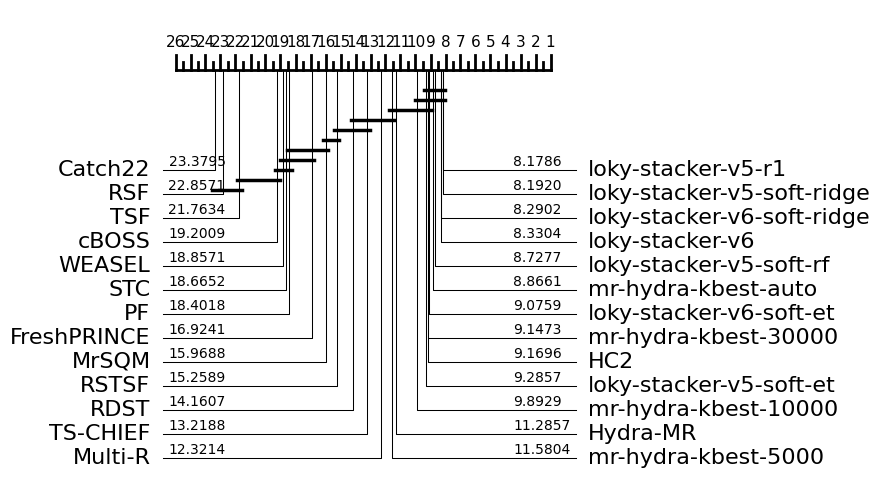

In [12]:
clsf = df_performance_full.select([c for c in df_performance_full.columns if c != "dataset"])
plot_critical_difference(clsf.to_numpy(), clsf.columns)

In [13]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

df_performance_full.join(stats, on='dataset').sort('n_train')

Catch22,FreshPRINCE,HC2,Hydra-MR,MrSQM,Multi-R,PF,RDST,RSF,RSTSF,STC,TS-CHIEF,TSF,WEASEL,cBOSS,dataset,mr-hydra-kbest-5000,loky-stacker-v6-soft-ridge,loky-stacker-v6,mr-hydra-kbest-auto,mr-hydra-kbest-10000,mr-hydra-kbest-30000,loky-stacker-v6-soft-et,loky-stacker-v5-soft-et,loky-stacker-v5-soft-ridge,loky-stacker-v5-soft-rf,loky-stacker-v5-r1,n_train,n_test,n_classes,series_length
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
0.908279,0.916993,0.946841,0.950436,0.890741,0.952179,0.956754,0.944989,0.919935,0.937146,0.924619,0.945861,0.940632,0.894553,0.881046,"""DiatomSizeReduction""",0.948366,0.944853,0.956972,0.96179,0.951828,0.953548,0.946821,0.95915,0.96732,0.951797,0.95679,16,306,4,345
0.986613,0.999866,0.999331,0.984739,0.857028,0.996252,1.0,0.965194,1.0,1.0,0.905087,1.0,1.0,1.0,0.998527,"""InsectEPGSmallTrain""",1.0,1.0,0.995538,1.0,1.0,0.999476,1.0,1.0,1.0,0.998661,0.997992,17,249,3,601
0.851667,0.881667,0.911667,0.911667,0.963333,0.895,0.86,0.926667,0.875,0.885,0.951667,0.958333,0.823333,0.92,0.96,"""BeetleFly""",0.921667,0.865,0.904167,0.92,0.926923,0.915217,0.9,0.8875,0.8875,0.8625,0.925,20,20,2,512
0.888333,0.923333,0.946667,0.91,0.958333,0.89,0.903333,0.913333,0.833333,0.963333,0.915,0.963333,0.821667,0.906667,0.981667,"""BirdChicken""",0.908333,0.935,0.935,0.917857,0.909091,0.9,1.0,0.933333,0.95,0.9625,0.941667,20,20,2,512
0.892323,0.972789,0.970068,0.965792,0.95345,0.966569,0.948019,0.968416,0.883479,0.975607,0.955102,0.961836,0.954227,0.939456,0.942857,"""Chinatown""",0.970068,0.97501,0.968347,0.968578,0.970012,0.966029,0.971641,0.96793,0.97036,0.974344,0.969596,20,343,2,24
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.792152,0.847708,0.843706,0.859402,0.816861,0.857964,0.829099,0.829099,0.817211,0.841414,0.833877,0.82533,0.811772,0.811305,0.780109,"""PhalangesOutlinesCorrect""",0.842424,0.863753,0.861835,0.85678,0.84714,0.853454,0.858042,0.860723,0.868998,0.861072,0.857032,1800,858,2,80
0.908636,1.0,0.953712,0.955354,0.95,0.954141,0.850025,0.949242,0.876515,0.977803,0.934242,0.947399,0.81846,0.960657,0.908939,"""FordA""",0.956288,0.979167,0.98416,0.956267,0.955886,0.95487,0.98447,0.986515,0.980682,0.986364,0.983996,3601,1320,2,500
0.867778,0.9207,0.933868,0.931193,0.922798,0.929671,0.839383,0.928601,0.85786,0.922593,0.9193,0.919465,0.785267,0.928354,0.883086,"""FordB""",0.929095,0.940895,0.940201,0.936529,0.931327,0.929405,0.935185,0.943519,0.935802,0.92134,0.94321,3636,810,2,500


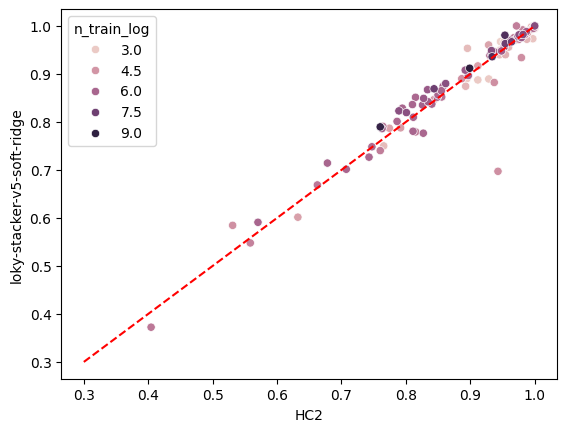

In [14]:
m1 = 'HC2'
m2 = 'loky-stacker-v5-soft-ridge'
data = df_performance_full.join(stats, on='dataset').with_columns(pl.col('n_train').log().alias('n_train_log')).sort('n_train')
sns.scatterplot(data=data.to_pandas(), x=m1, y=m2, hue='n_train_log')
#plt.scatter(clsf[m1], clsf[m2], alpha=0.7, edgecolors='b', s=5)
plt.xlabel(m1)
plt.ylabel(m2)
plt.plot([0.3, 1], [0.3, 1], 'r--')

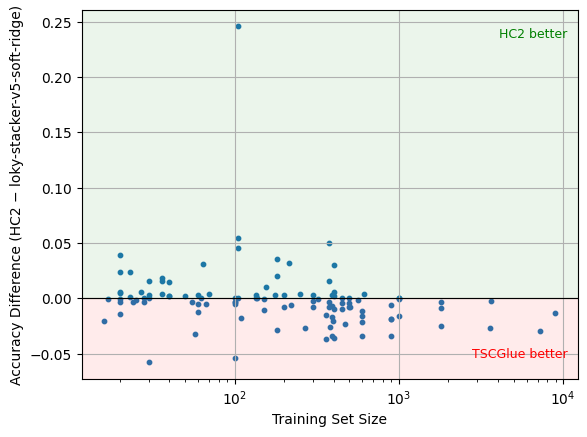

In [15]:
plt.scatter(data['n_train'], data[m1]-data[m2], s=10)
plt.xlabel('Training Set Size')
plt.ylabel(f'Accuracy Difference ({m1} − {m2})')
plt.xscale('log')
plt.grid()
plt.axhline(0, color='black', linewidth=0.8)
ylim = plt.gca().get_ylim()
plt.axhspan(0, ylim[1], alpha=0.08, color='green')
plt.axhspan(ylim[0], 0, alpha=0.08, color='red')
plt.text(0.98, 0.95, 'HC2 better', transform=plt.gca().transAxes, ha='right', va='top', fontsize=9, color='green')
plt.text(0.98, 0.05, 'TSCGlue better', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=9, color='red')
plt.ylim(ylim)

directory = "figures"
Path(directory).mkdir(parents=True, exist_ok=True)

plt.savefig(f"{directory}/train_size.pdf", bbox_inches='tight', pad_inches=0)

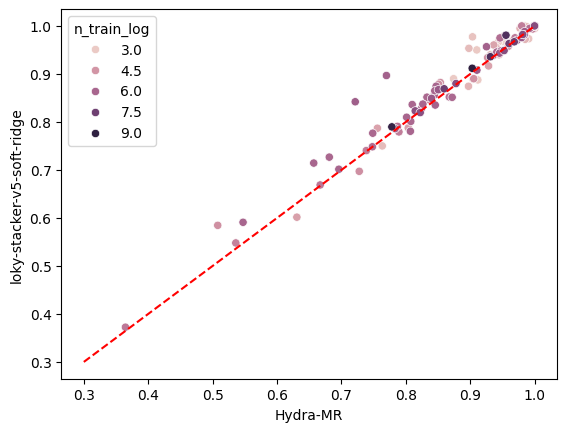

In [16]:
m1 = 'Hydra-MR'
m2 = 'loky-stacker-v5-soft-ridge'
data = df_performance_full.join(stats, on='dataset').with_columns(pl.col('n_train').log().alias('n_train_log')).sort('n_train')
sns.scatterplot(data=data.to_pandas(), x=m1, y=m2, hue='n_train_log')
#plt.scatter(clsf[m1], clsf[m2], alpha=0.7, edgecolors='b', s=5)
plt.xlabel(m1)
plt.ylabel(m2)
plt.plot([0.3, 1], [0.3, 1], 'r--')

(-0.13475576923076918, 0.03831559829059829)

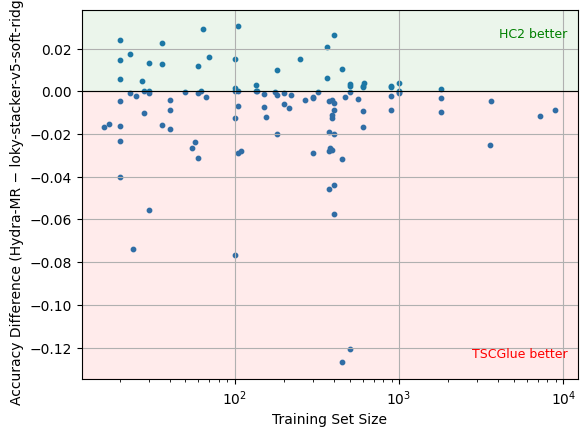

In [17]:
plt.scatter(data['n_train'], data[m1]-data[m2], s=10)
plt.xlabel('Training Set Size')
plt.ylabel(f'Accuracy Difference ({m1} − {m2})')
plt.xscale('log')
plt.grid()
plt.axhline(0, color='black', linewidth=0.8)
ylim = plt.gca().get_ylim()
plt.axhspan(0, ylim[1], alpha=0.08, color='green')
plt.axhspan(ylim[0], 0, alpha=0.08, color='red')
plt.text(0.98, 0.95, 'HC2 better', transform=plt.gca().transAxes, ha='right', va='top', fontsize=9, color='green')
plt.text(0.98, 0.05, 'TSCGlue better', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=9, color='red')
plt.ylim(ylim)

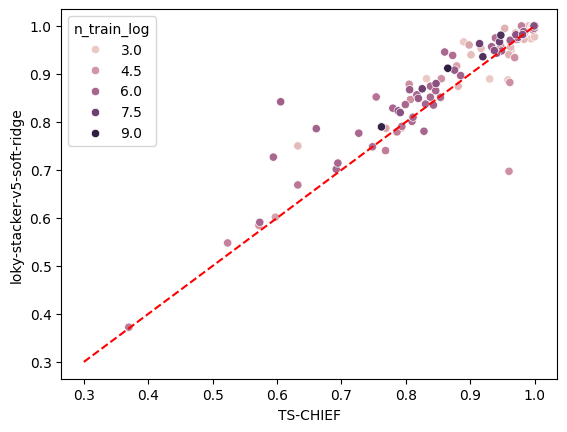

In [18]:
m1 = 'TS-CHIEF'
m2 = 'loky-stacker-v5-soft-ridge'
data = df_performance_full.join(stats, on='dataset').with_columns(pl.col('n_train').log().alias('n_train_log')).sort('n_train')
sns.scatterplot(data=data.to_pandas(), x=m1, y=m2, hue='n_train_log')
#plt.scatter(clsf[m1], clsf[m2], alpha=0.7, edgecolors='b', s=5)
plt.xlabel(m1)
plt.ylabel(m2)
plt.plot([0.3, 1], [0.3, 1], 'r--')

(-0.2613690384615384, 0.28794980769230755)

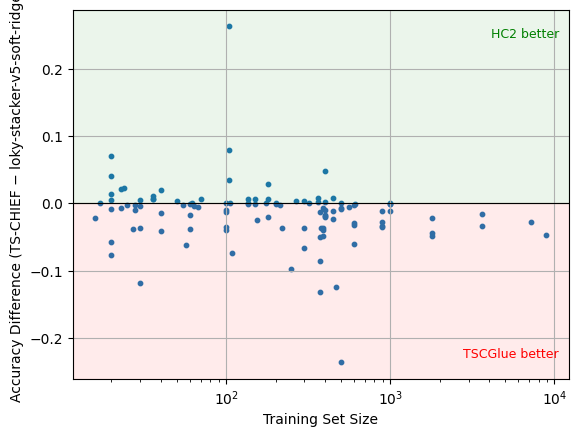

In [19]:
plt.scatter(data['n_train'], data[m1]-data[m2], s=10)
plt.xlabel('Training Set Size')
plt.ylabel(f'Accuracy Difference ({m1} − {m2})')
plt.xscale('log')
plt.grid()
plt.axhline(0, color='black', linewidth=0.8)
ylim = plt.gca().get_ylim()
plt.axhspan(0, ylim[1], alpha=0.08, color='green')
plt.axhspan(ylim[0], 0, alpha=0.08, color='red')
plt.text(0.98, 0.95, 'HC2 better', transform=plt.gca().transAxes, ha='right', va='top', fontsize=9, color='green')
plt.text(0.98, 0.05, 'TSCGlue better', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=9, color='red')
plt.ylim(ylim)